In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.integrate import quad
from scipy.differentiate import derivative
import scipy.integrate as integrate
from matplotlib import animation
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter
from traitlets import Any

In [83]:
#time varying function for control
def f(t,args):
    T = args['T']
    return t/T #np.sin(np.pi * t / (2 * T))**2 #t/T

In [84]:
a = 0.5
b = 0.2 #time-independent coupling constant
c = 0.1 #to avoid system-crossing between first and second eigenenergy level
d = 2
# T = 5000 #time evolution interval
# args = {'T': T_curr}
t=0
# t_list=np.linspace(0,T,1001) #time-stepping

In [85]:
#Static and Dynamic Hamiltonian
def H_static(a,b,c):
    data=[[a,b,0],[b,-a,c],[0,c,0]]
    return qt.Qobj(data)

def H_dynamic(d):
    data1=[[-1,0,0],[0,1,0],[0,0,d]]
    return qt.Qobj(data1)


In [86]:
#initial hamiltonian
# H_t=H_static+(f(t,args)*H_dynamic(d))
T_curr=1000
# args['T']=T_curr
args={'T':T_curr}
def H(t,args):
    return H_static(a,b,c)+(f(t,args)*H_dynamic(d))
eigenvalue,eigenvector=H(t,args).eigenstates()
psi0=eigenvector[0]
#total hamiltonian
H_total=[H_static(a,b,c),[H_dynamic(d),f]]

In [89]:
H(1,args)

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.499  0.2    0.   ]
 [ 0.2   -0.499  0.1  ]
 [ 0.     0.1    0.002]]

SINGLE T (Ajust TT)

In [90]:
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
transition_probability_full,error_full_list=[],[]
adiabatic_error_full=[]
# T_curr=1000
# args['T'] = T_curr
t_list1 = np.linspace(0, T_curr, 100)
T1=t_list1

listy.append(t_list1)
final = qt.sesolve(H_total, psi0, t_list1, args=args)
transition_probability=[]
ground_temp,first_temp,second_temp=[],[],[]
adiabatic_error_temp,errors_fidelity_temp=[],[]
error_temp=[]
for i, t in enumerate(t_list1):
    s = t / T_curr  # scaled time, s ∈ [0, 1]

    def H_at_s(s):
        return H_static(a,b,c) + s * H_dynamic(d)

    evals, estates = H(t,args).eigenstates()
    ground_temp.append(evals[0])
    first_temp.append(evals[1])
    second_temp.append(evals[2])

    fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
    transition_probability.append(1 - fidelity)

    #final.states[i] = instantaneous ground state of the Hamiltonian
    #estates[0] = exact 'time-evolved' state of the initial Hamiltonian/sub-space
    # fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
    # adiabatic_error_temp.append(np.sqrt(1 - fidelity))  # phase-invariant distance

    diff_vector = estates[0] - final.states[i]
    vector_distance = np.linalg.norm(diff_vector.full(), ord=2)
    adiabatic_error_temp.append(vector_distance)

    m = 1

    # dH/ds = H_dynamic (exact, since H(s) = H_static + s * H_dynamic)
    def dH_ds():
        return np.linalg.norm(H_dynamic(d).full(), ord=2)

    def bandgap_func(s):
        evals, _ = H_at_s(s).eigenstates()
        return float(evals[1] - evals[0])
    # d²H/ds² = 0 for linear interpolation, so the Ḧ term vanishes
    # Integrand: 7m√m * ||dH/ds||² / g(s')³
    def integrand(s):
        g = bandgap_func(s)
        return (dH_ds()**2) / g**3

    dH_dot_norm = dH_ds()
    g0 = bandgap_func(0)
    gs = bandgap_func(s)

    # Boundary term (|u.b. means evaluated at 0 and s)
    ub_boundary = (m * dH_dot_norm /T_curr) * (1/g0**2 + 1/gs**2)

    # Integral term — integrate over s', from 0 to s
    ub_integral, _ = integrate.quad(integrand, 0, s)
    ub_integral *= (7 * m * np.sqrt(m)) / T_curr

    total_equation = ub_boundary + ub_integral
    error_temp.append(total_equation)

ground_full_T.append(ground_temp)
first_full_T.append(first_temp)
second_full_T.append(second_temp)
adiabatic_error_full.append(adiabatic_error_temp)
transition_probability_full.append(transition_probability)
error_full_list.append(error_temp)


Multiple T

In [93]:
T1=np.linspace(100,5000,50)
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
transition_probability_full,error_full_list=[],[]
adiabatic_error_full=[]

for T_curr in T1:
    args['T'] = T_curr
    # H_t=H_static+(f(t,args)*H_dynamic(d))
    eigenvalue,eigenvector=H(0,args).eigenstates()
    psi0=eigenvector[0]
    #total hamiltonian
    H_total=[H_static(a,b,c),[H_dynamic(d),f]]
    # dt = 100  # fixed spacing
    # n_points = max(100, int(T_curr / dt))
    t_list1 = np.linspace(0, T_curr, 100)
    listy.append(t_list1)
    final = qt.sesolve(H_total, psi0, t_list1, args=args)
    transition_probability=[]
    ground_temp,first_temp,second_temp=[],[],[]
    adiabatic_error_temp,errors_fidelity_temp=[],[]
    error_temp=[]
    for i, t in enumerate(t_list1):
        s = t / T_curr  # scaled time, s ∈ [0, 1]

        def H_at_s(s):
            return H_static(a,b,c) + s * H_dynamic(d)

        def bandgap_func(s):
            evals, _ = H_at_s(s).eigenstates()
            return float(evals[1] - evals[0])

        evals, estates = H_at_s(s).eigenstates()
        ground_temp.append(evals[0])
        first_temp.append(evals[1])
        second_temp.append(evals[2])

        fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
        transition_probability.append(1 - fidelity)

        # overlap = estates[0].overlap(final.states[i])
        # phase = overlap / np.abs(overlap)  # e^{iφ}
        # diff_vector = final.states[i] - phase * estates[0]
        # vector_distance = np.linalg.norm(diff_vector.full(), ord=2)

        # diff_vector = final.states[i] - estates[0]
        # vector_distance = np.linalg.norm(diff_vector.full(), ord=2)
        # adiabatic_error_temp.append(vector_distance)

        # Correct implementation of ||P_tau(s) - P(s)||
        # psi_t = final.states[i]        # time-evolved state
        # e0 = estates[0]                # instantaneous ground state
        # P_tau = psi_t * psi_t.dag()   # outer product
        # P_s   = e0 * e0.dag()         # outer product
        # diff_projector = P_tau - P_s
        # vector_distance = diff_projector.norm()  # operator norm
        # adiabatic_error_temp.append(vector_distance)

        P_instantaneous=estates[0]*estates[0].dag() #outer product
        P_exact=final.states[i].proj() #outer product
        vector_distance=(P_instantaneous-P_exact).norm()

        # overlapy = abs(estates[0].overlap(final.states[i]))**2
        # vector_distance = np.sqrt(max(0.0, 2 - 2*np.sqrt(overlapy)))
        adiabatic_error_temp.append(vector_distance)


        m = 1

        # dH/ds = H_dynamic (exact, since H(s) = H_static + s * H_dynamic)
        def dH_ds():
            return np.linalg.norm(H_dynamic(d).full(), ord=2)

        # d²H/ds² = 0 for linear interpolation, so the Ḧ term vanishes
        # Integrand: 7m√m * ||dH/ds||² / g(s')³
        def integrand(s):
            g = bandgap_func(s)
            return (dH_ds()**2) / g**3

        dH_dot_norm = dH_ds()
        g0 = bandgap_func(0)
        gs = bandgap_func(s)

        # Boundary term (|u.b. means evaluated at 0 and s)
        ub_boundary = (m * dH_dot_norm /T_curr) * (1/g0**2 + 1/gs**2)

        # Integral term — integrate over s', from 0 to s
        ub_integral, _ = integrate.quad(integrand, 0, s)
        ub_integral *= (7 * m * np.sqrt(m)) / T_curr

        total_equation = ub_boundary + ub_integral
        error_temp.append(total_equation)

    ground_full_T.append(ground_temp)
    first_full_T.append(first_temp)
    second_full_T.append(second_temp)
    adiabatic_error_full.append(adiabatic_error_temp)
    transition_probability_full.append(transition_probability)
    error_full_list.append(error_temp)

In [ ]:
#print(final.states[2].norm(),estates[0].norm(),H(1,args:[1000]))

GRAPHICAL PLOTS

In [ ]:
#b loop


In [9]:
print(end_error_per_T)
errorbound_per_T

NameError: name 'end_error_per_T' is not defined

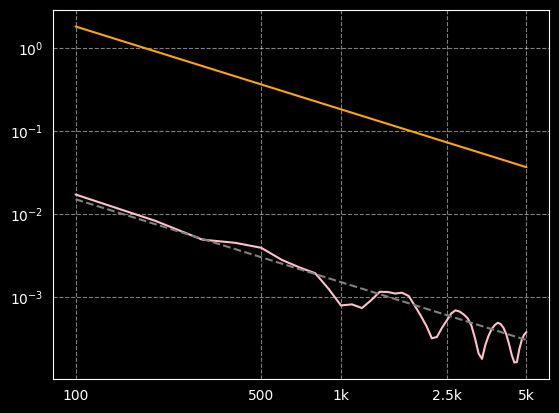

In [94]:
# max_errors_per_T = [max(errors) for errors in transition_probability_full]
# max_errorbound_per_T = [max(errors) for errors in error_full_list]
end_error_per_T = [errors[-1] for errors in adiabatic_error_full]
errorbound_per_T = [errors[-1] for errors in error_full_list]

plt.figure()
# plt.loglog(T1, max_errors_per_T,'-',color='darkviolet')
# plt.loglog(T1, max_errorbound_per_T,'-',color='orange')
plt.loglog(T1, end_error_per_T,'-',color='pink')
plt.loglog(T1, errorbound_per_T,'-',color='orange')
plt.loglog(T1, 1.5/T1, '--', label='Theoretical Slope', color='gray')
# plt.xticks([100, 500, 1000, 2500, 5000,10000], ['100', '500', '1k', '2.5k', '5k','10k'])
plt.xticks([100, 500, 1000, 2500, 5000], ['100', '500', '1k', '2.5k', '5k'])
plt.grid(True, ls="--", alpha=0.5)
plt.show()

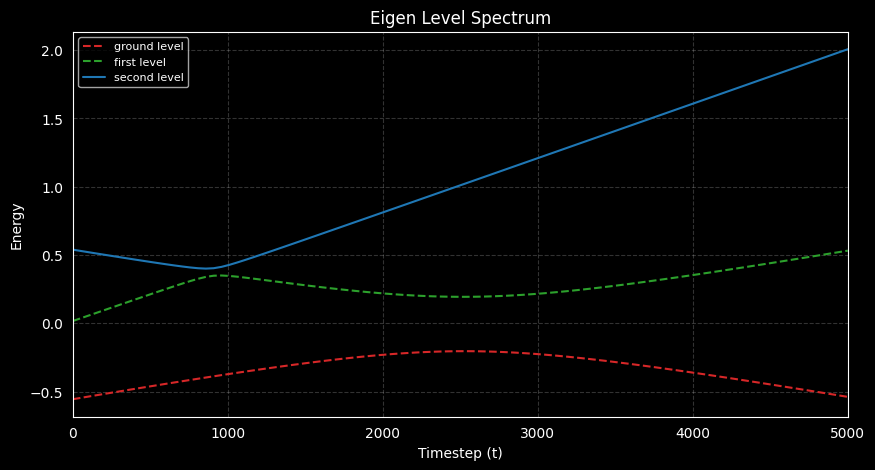

In [95]:
# #Spectrum vs T
plt.figure(figsize=(10,5))
plt.plot(listy[-1], ground_temp, color='tab:red', linestyle='--', label='ground level')
plt.plot(listy[-1],first_temp , color='tab:green', linestyle='--', label='first level')
plt.plot(listy[-1], second_temp, color='tab:blue', linestyle='-', label='second level')
plt.title('Eigen Level Spectrum')
plt.xlabel('Timestep (t)')
plt.ylabel('Energy')
plt.legend(fontsize=8)
plt.autoscale(enable=True, axis='x', tight=True)
plt.grid(linestyle='--',alpha=0.2)



At T =  5000.0


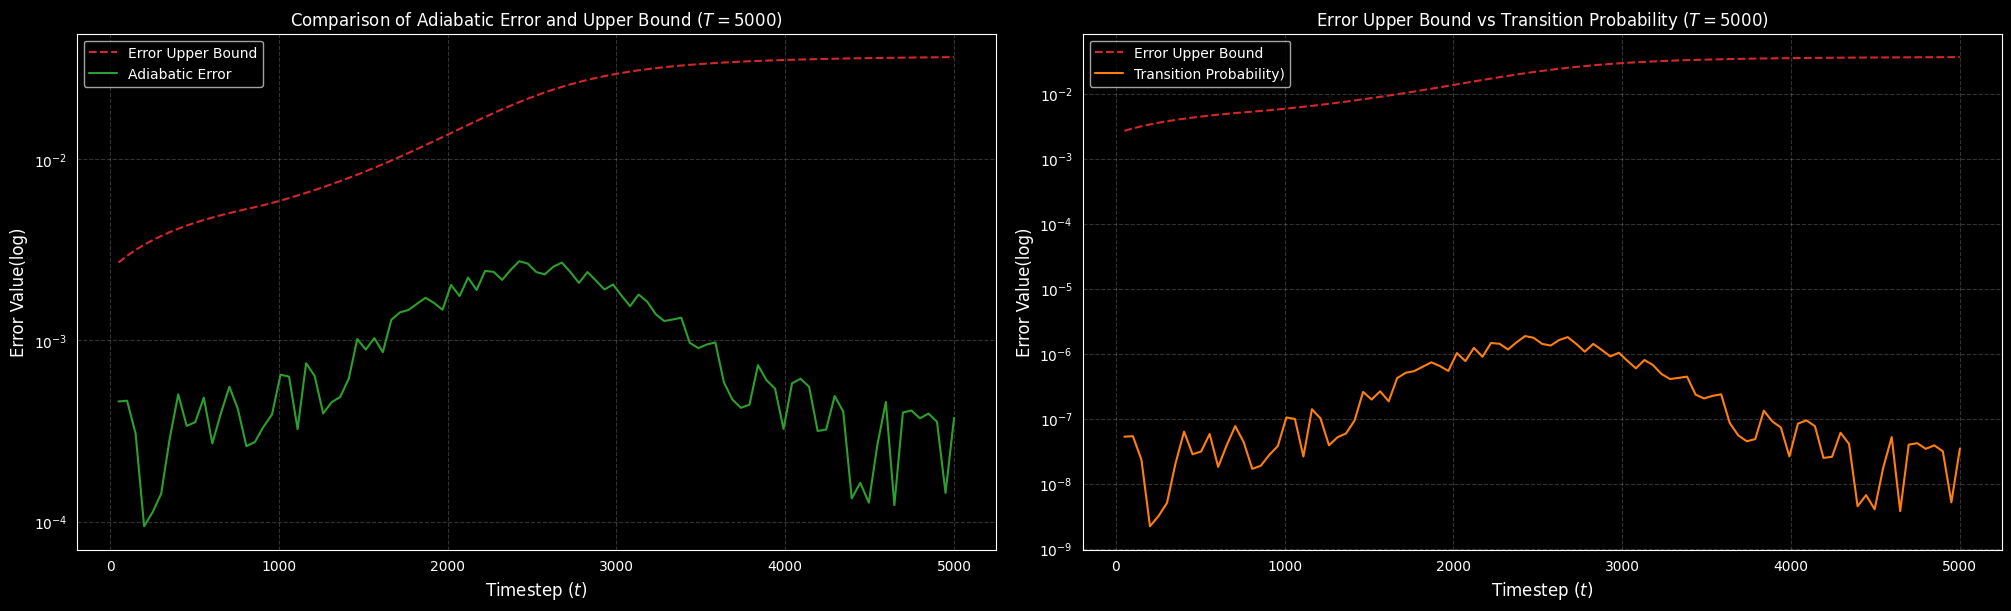

0.00037336694804202485


In [98]:
k=-1
print('At T = ',T1[k])
fig, ax = plt.subplots(1, 2, figsize=(20, 6), layout='constrained')

# --- LEFT GRAPH (ax[0]) ---
ax[0].plot(listy[k][1:], error_full_list[k][1:],'--', color='tab:red', label='Error Upper Bound')
ax[0].plot(listy[k][1:], adiabatic_error_full[k][1:],  color='tab:green', label='Adiabatic Error')
ax[0].set_ylabel('Error Value(log)', fontsize=12)
ax[0].set_xlabel('Timestep ($t$)', fontsize=12)
ax[0].set_yscale('log')
ax[0].legend()
ax[0].set_title(f'Comparison of Adiabatic Error and Upper Bound ($T={round(T1[k])}$)')
ax[0].grid(linestyle='--', alpha=0.2)

# --- RIGHT GRAPH (ax[1]) ---
ax[1].plot(listy[k][1:], error_full_list[k][1:], '--',color='tab:red',label='Error Upper Bound ')
ax[1].plot(listy[k][1:], transition_probability_full[k][1:], color='tab:orange', label='Transition Probability)')
ax[1].set_ylabel('Error Value(log)', fontsize=12)
ax[1].set_xlabel('Timestep ($t$)', fontsize=12)
ax[1].set_yscale('log')
ax[1].legend()
ax[1].set_title(f'Error Upper Bound vs Transition Probability ($T={round(T1[k])}$)')
ax[1].grid(linestyle='--', alpha=0.2)

plt.show()
print(adiabatic_error_full[-1][-1])

In [221]:
print('end_error_per_T = ',round(end_error_per_T[0],4))

end_error_per_T =  0.00572


At T =  5000.0


Text(68.56521809895833, 0.5, 'Error Magnitude (log)')

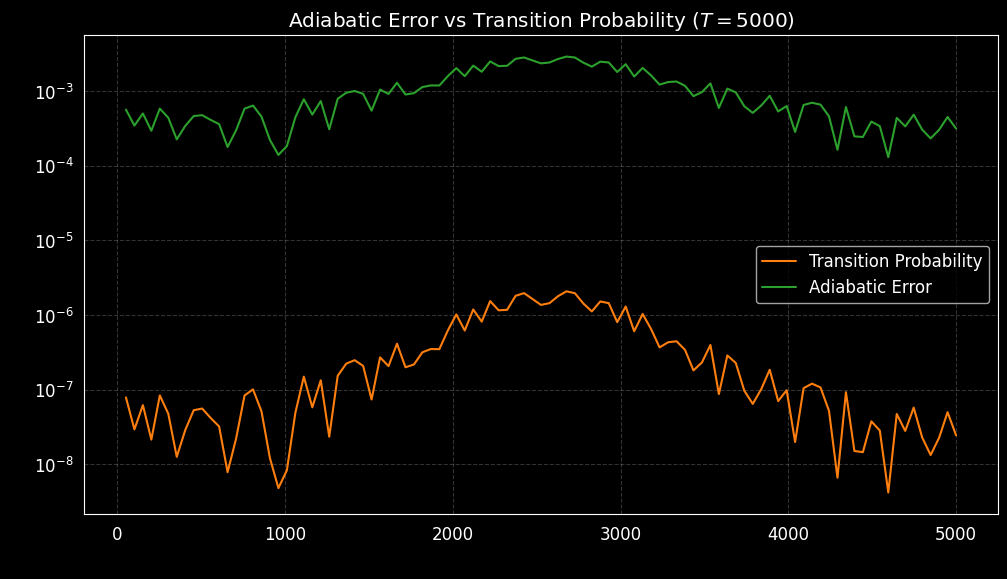

In [156]:
#Visulatization; Comparison of Error Metrics vs Transition Probability
print('At T = ', T1[k])
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(listy[k][1:], transition_probability_full[k][1:], color='tab:orange', label='Transition Probability')
ax1.plot(listy[k][1:], adiabatic_error_full[k][1:], color='tab:green', label='Adiabatic Error')
ax1.set_yscale('log') # Both metrics are best viewed on a log scale
ax1.grid(True, which="major", ls="--", alpha=0.2)
ax1.set_title(f'Adiabatic Error vs Transition Probability ($T={round(T1[k])}$)')
ax1.legend()
fig.tight_layout(rect=[0, 0, 1, 0.95])
ax1.set_xlabel('Time ($t$)', fontsize=12)
ax1.set_ylabel('Error Magnitude (log)', fontsize=12)
# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, facecolor='yellow')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6),layout='constrained')
Approximate_Error= ax.plot(listy[k][1:], error_full_list[k][1:], color='tab:red',label='Error Upper Bound')
Ideal_Error=ax.plot(listy[k][1:],  adiabatic_error_full[k][1:],'--', color='tab:green',label='Adiabatic Error')
ax.set_ylabel('Error Value(log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_yscale('log')
ax.legend()
ax.set_title('Error vs Timestep')
plt.grid(linestyle='--',alpha=0.2)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6),layout='constrained')
Approximate_Error= ax.plot(listy[k], error_full_list[k], color='tab:red',label='Error Upper Bound')
Ideal_Error=ax.plot(listy[k], transition_probability_full[k],'--', color='tab:blue',label='Adiabatic Error')
ax.set_ylabel('Error Value(log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_yscale('log')
ax.legend()
ax.set_title('Error vs Timestep')
plt.grid(linestyle='--',alpha=0.5)

ANIMATION

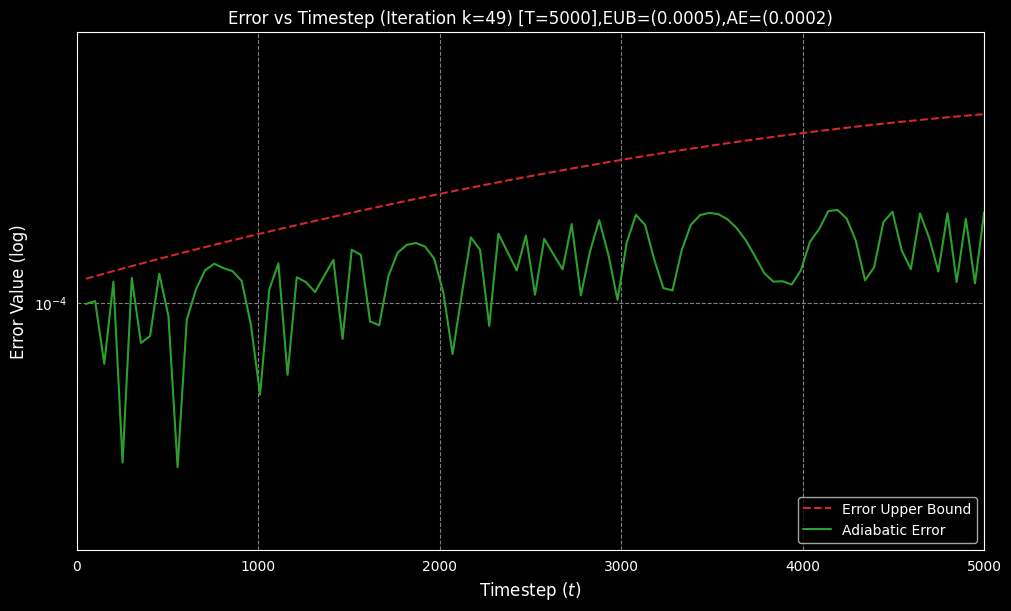

In [71]:
fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')
ax.set_yscale('log')
ax.set_ylabel('Error Value (log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_title('Error vs Timestep Animation')
plt.grid(linestyle='--', alpha=0.5)
line_approx, = ax.plot([], [], '--', color='tab:red', label=f'Error Upper Bound')#({round(errorbound_per_T[k], 4)})
line_ideal, = ax.plot([], [], color='tab:green', label=f'Adiabatic Error')# ({round(end_error_per_T[k], 4)})


def update(k):

    # line_tp, = ax.plot([], [], color='tab:orange', label='Transition Probability')
    ax.legend(loc='lower right')
    ax.set_ylim((min(sorted(list(adiabatic_error_full[k]))[1],sorted(list(error_full_list[k]))[0])*(1-1/2)), (max(error_full_list[k][1:])*(1+1))) #here max() should have the highest value(adiabatic error or ideal error).
    # ax.set_ylim((min(transition_probability_full[k][1:])*(1-1/2)), (max(error_full_list[k][1:])*(1+1)))
    ax.set_xlim(min(listy[0]), max(listy[k]))
    x_data = listy[k][1:]
    y_approx = error_full_list[k][1:]
    y_ideal = adiabatic_error_full[k][1:]
    # y_tp = transition_probability_full[k][1:]
    line_approx.set_data(x_data, y_approx)
    line_ideal.set_data(x_data, y_ideal)
    # line_tp.set_data(x_data, y_tp)
    ax.set_title(f'Error vs Timestep (Iteration k={k}) [T={round(T1[k])}],EUB=({round(errorbound_per_T[k], 4)}),AE=({round(end_error_per_T[k], 4)})')
    return line_approx, line_ideal, #line_tp

fps = 5 #earlier, it was 10. interval unit is in ms.
ani = FuncAnimation(fig, update, frames=len(error_full_list),interval=1000/fps, blit=True)
ani.save(r'/home/pravin/Desktop/Physik 2025/AQC Project/Large Band Gap/error_animation.gif', writer=PillowWriter(fps=fps))
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,6),layout='constrained')
ax.set_yscale('log')
ax.set_ylabel('Error Value (log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_title('Error vs Timestep Animation')
plt.grid(linestyle='--', alpha=0.5)

line_approx, = ax.plot([], [], '--', color='tab:red', label='Error Upper Bound')
line_tp, = ax.plot([], [], color='tab:orange', label='Transition Probability')
ax.legend()
ax.set_xlim(min(listy[0]), max(listy[-1]))
# ax.set_ylim(1e-8, 5)

def update(k):
    ax.set_ylim((min(transition_probability_full[k][1:])*(1-1/2)), (max(error_full_list[k][1:])*(1+1)))
    ax.set_xlim(min(listy[0]), max(listy[k]))
    x_data = listy[k][1:]
    y_approx = error_full_list[k][1:]
    y_ideal = transition_probability_full[k][1:]
    line_approx.set_data(x_data, y_approx)
    line_tp.set_data(x_data, y_ideal)
    ax.set_title(f'Error vs Timestep (Iteration k={k} [T={round(T1[k])}])')

    return line_approx, line_ideal

ani = FuncAnimation(fig, update, frames=len(error_full_list),
                    interval=100, blit=True)

ani.save(r'/home/pravin/Desktop/Physik 2025/AQC Project/error_animation1_updated_new.gif', writer='pillow')
plt.show()

TO BE DELETED

In [ ]:
#for f vs T
f_values = [f(t, args) for t in t_list]
fidelity_values = [1 - err for err in errors_fidelity]
plt.figure()
plt.plot(t_list, f_values)
plt.title('Function f vs Timestep')
plt.xlabel('Timestep (t)')
plt.ylabel('f(t)')
plt.grid()
plt.show()

In [ ]:
max_error=np.argmax(error)
max_error_1=np.argmax(errors_fidelity)
time_at_error_peak=t_list[max_error]
error_value_at_peak=errors_fidelity[max_error_1]
error_upper_bound_value_at_peak=error[max_error]
Difference_in_error=error_value_at_peak-error_upper_bound_value_at_peak

print('Peak Error Time: ',time_at_error_peak)
print('Error: ',error_value_at_peak)
print('Upper Bound Error: ',error_upper_bound_value_at_peak)
print('Difference between Error and EUB: ',Difference_in_error)


In [ ]:
#single T backup
TT=1000
T1=np.linspace(TT,TT,1)
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
transition_probability_full,error_full_list=[],[]
adiabatic_error_full=[]

for T_curr in T1:
    args['T'] = T_curr
    t_list1 = np.linspace(0, T_curr, 200)
    listy.append(t_list1)
    final = qt.sesolve(H_total, psi0, t_list1, args=args)
    transition_probability=[]
    ground_temp,first_temp,second_temp=[],[],[]
    adiabatic_error_temp,errors_fidelity_temp=[],[]
    error_temp=[]
    for i,t in enumerate(t_list1):
        # s=t/T_curr

        # f_val = f(t, args)

        def f_val(t):
            return f(t, args)
        def H_t(t):#instantaneous_Hamiltonian
            return H_static + f_val(t) * H_dynamic(d)
        evals, estates = H_t(t).eigenstates()
        ground_temp.append(evals[0])
        first_temp.append(evals[1])
        second_temp.append(evals[2])

        fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
        transition_probability.append(1 - fidelity)

        #Norm
        diff_vector = final.states[i] - estates[0]
        vector_distance = np.linalg.norm(diff_vector.full(),ord=2)
        adiabatic_error_temp.append(vector_distance)

        # Upper Bound for ERROR
        m = 1
        def dH_1_norm(b):
            dH_1 = (H_dynamic(d)/T_curr).full()
            return np.linalg.norm(dH_1,ord=2)

        def bandgap_func(t):
            eigenvalue1,eigenvector1=H_t(t).eigenstates()
            gg=eigenvalue1[1]-eigenvalue1[0]
            return gg.item()

        def dH_1_norm_squared(t):
            dH_11=dH_1_norm(b)
            g1=bandgap_func(t)
            return dH_11**2/g1**3

        ub_1 = m * dH_1_norm(b) * ((1 / bandgap_func(0) ** 2)+(1/bandgap_func(t) ** 2))
        ub_4 = integrate.quad(dH_1_norm_squared, 0, t)
        total_equation = ub_1  + (ub_4[0] * 7 * m * np.sqrt(m))
        error_temp.append(total_equation)

    ground_full_T.append(ground_temp)
    first_full_T.append(first_temp)
    second_full_T.append(second_temp)
    adiabatic_error_full.append(adiabatic_error_temp)
    transition_probability_full.append(transition_probability)
    error_full_list.append(error_temp)


In [ ]:
#multi T backup
T1=np.linspace(100,5000,100)
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
transition_probability_full,error_full_list=[],[]
adiabatic_error_full=[]

for T_curr in T1:
    args['T'] = T_curr
    t_list1 = np.linspace(0, T_curr, 200)
    listy.append(t_list1)
    final = qt.sesolve(H_total, psi0, t_list1, args=args)
    transition_probability=[]
    ground_temp,first_temp,second_temp=[],[],[]
    adiabatic_error_temp,errors_fidelity_temp=[],[]
    error_temp=[]
    for i,t in enumerate(t_list1):
        f_val = f(t, args)
        H_t = H_static + f_val * H_dynamic(b)
        evals, estates = H_t.eigenstates()
        ground_temp.append(evals[0])
        first_temp.append(evals[1])
        second_temp.append(evals[2])
        fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
        transition_probability.append(1 - fidelity)

        #Norm
        diff_vector = estates[0] - final.states[i]
        diff_vector_converted = diff_vector.full()
        vector_distance = np.linalg.norm(diff_vector_converted,ord=2)
        adiabatic_error_temp.append(vector_distance)

        # Upper Bound for ERROR
        m = 1
        def dH_1_norm(b):
            dH_1 = (H_dynamic(b)/T_curr).full()
            return np.linalg.norm(dH_1,ord=2)
        def dH_1_norm_squared(t):
            dH_11=dH_1_norm(b)
            f_value=f(t, args)
            H_tt = H_static + f_value * H_dynamic(b)
            eigenvalue1,eigenvector1=H_tt.eigenstates()
            g1=eigenvalue1[1]-eigenvalue1[0]
            gg=dH_11**2/g1**3
            return gg
        def bandgap_func(t):
            f_value=f(T_curr, args)
            H_tt = H_static + f_value * H_dynamic(b)
            eigenvalue1,eigenvector1=H_tt.eigenstates()
            gg=eigenvalue1[1]-eigenvalue1[0]
            return gg.item()

        ub_1 = m * dH_1_norm(b) * ((1 / bandgap_func(0) ** 2)+(1/bandgap_func(T_curr) ** 2))
        ub_4 = integrate.quad(dH_1_norm_squared, 0, t)
        total_equation = ub_1  + (ub_4[0] * 7 * m * np.sqrt(m))
        error_temp.append(total_equation)


    ground_full_T.append(ground_temp)
    first_full_T.append(first_temp)
    second_full_T.append(second_temp)
    adiabatic_error_full.append(adiabatic_error_temp)
    transition_probability_full.append(transition_probability)
    error_full_list.append(error_temp)